# Notebook 03 - Modèles Économétriques
**Projet :** Cadre méthodologique pour la prévision du crédit bancaire dans l'UEMOA basé sur une comparaison entre modèles économétriques et de machine learning : application au Bénin

**Phase :** ARDL (Bénin, T=25) + Panel Effets Fixes UEMOA (N=8, T=25)

**Décisions Notebook 02 :** credit I(1) : ARDL ; Mundlak F=25.9 : FE ; BP : SE clustered

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.ardl import ARDL, ardl_select_order
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tools import add_constant
from statsmodels.regression.linear_model import OLS
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from linearmodels.panel import PanelOLS
    LM_AVAILABLE = True
    print('linearmodels disponible')
except ImportError:
    LM_AVAILABLE = False
    print('linearmodels absent - fallback OLS within')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_PATH = Path('../data/panel_uemoa_complet.csv')
FIG_PATH  = Path('../figures')
FIG_PATH.mkdir(exist_ok=True)

linearmodels disponible


In [2]:
def compute_metrics(y_true, y_pred, label=''):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]
    result = {
        'RMSE':     np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':      mean_absolute_error(y_true, y_pred),
        'R²':       r2_score(y_true, y_pred),
        'MAPE (%)': np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    }
    if label:
        print(f'\n=== Métriques - {label} ===')
        for k, v in result.items():
            print(f'  {k:<12} {v:.4f}')
    return result


def ardl_fitted_manual(ardl_model, ardl_res, endog_series, exog_df):
    """
    Calcule les valeurs ajustées in-sample via X @ beta.
    Contourne le bug statsmodels 0.14 (fittedvalues -> predict() -> ValueError).
    ardl_model.exog retourne l'exog original (T×k_orig), pas la matrice de design
    complète. On la reconstruit depuis params.index pour avoir la bonne dimension.
    Retourne (y_hat, hold_back, X_design).
    """
    params = ardl_res.params
    hold   = ardl_model._hold_back
    T      = len(endog_series)
    n_eff  = T - hold

    cols = []
    for pname in params.index:
        if pname == 'const':
            cols.append(np.ones(n_eff))
        else:
            base, lag_str = pname.rsplit('.L', 1)
            lag = int(lag_str)
            if base == endog_series.name or 'credit_prive_pib' in base:
                cols.append(endog_series.values[hold - lag : T - lag])
            else:
                cols.append(exog_df[base].values[hold - lag : T - lag])

    X     = np.column_stack(cols)
    y_hat = X @ params.values
    return y_hat, hold, X


def ardl_forecast_recursive(ardl_res, endog_train, exog_train, exog_test):
    """
    Prévision OOS récursive (dynamique) pour ARDL.
    Analyse automatiquement les noms des paramètres (var.L{k}) pour
    construire la formule récursive, sans dépendre de predict() de statsmodels.
    """
    params    = ardl_res.params
    n_oos     = len(exog_test)
    T_train   = len(endog_train)
    exog_all  = pd.concat([exog_train, exog_test], ignore_index=False)
    credit_h  = list(endog_train.values)   # historique crédit (croît)

    preds = []
    for step in range(n_oos):
        pred = float(params.get('const', 0.0))
        for pname, coef in params.items():
            if pname == 'const' or '.L' not in pname:
                continue
            base, lag_str = pname.rsplit('.L', 1)
            lag = int(lag_str)
            if base == endog_train.name or 'credit_prive_pib' in base:
                if lag <= len(credit_h):
                    pred += float(coef) * credit_h[-lag]
            else:
                idx = T_train + step - lag
                if 0 <= idx < len(exog_all) and base in exog_all.columns:
                    pred += float(coef) * float(exog_all[base].iloc[idx])
        preds.append(pred)
        credit_h.append(pred)
    return np.array(preds)


## 1. Chargement des données

In [3]:
df = pd.read_csv(DATA_PATH)
df = df.sort_values(['iso3', 'annee']).reset_index(drop=True)
print(f'Panel : {df.shape[0]} obs × {df.shape[1]} variables')
print(f'Période : {df["annee"].min()}–{df["annee"].max()}')

Panel : 200 obs × 28 variables
Période : 2000–2024


---
## 2. Modèle ARDL - Bénin (T=25)

Justification : mélange I(0)/I(1), T=25, relation de long terme testable (ECM).

In [4]:
VARS_ARDL = [
    'masse_monetaire_m2_pib',
    'pib_croissance',
    'inflation_ipc',
    'bceao_taux_directeur',
    'imf_dette_publique',
    'ouverture_commerciale',
]

benin      = df[df['iso3'] == 'BEN'].sort_values('annee').copy()
benin_ardl = benin[['annee', 'credit_prive_pib'] + VARS_ARDL].set_index('annee')
benin_ardl = benin_ardl.interpolate(method='linear', limit=2).dropna()

print(f'Série Bénin : {len(benin_ardl)} obs ({benin_ardl.index.min()}–{benin_ardl.index.max()})')
print(f'Manquants : {benin_ardl.isnull().sum().sum()}')
benin_ardl.describe().T.round(3)

Série Bénin : 25 obs (2000–2024)
Manquants : 0


,count,mean,std,min,25%,50%,75%,max
credit_prive_pib,25.0000,14.3360,3.6130,7.1820,11.3150,15.8100,16.6960,18.9520
masse_monetaire_m2_pib,25.0000,24.7300,5.9470,14.0340,19.1890,26.1380,29.8320,33.4260
pib_croissance,25.0000,4.8570,1.8000,1.7130,3.4440,4.8970,6.3530,7.4530
inflation_ipc,25.0000,2.1980,2.1730,-0.7930,0.8740,1.4870,3.0230,7.9470
bceao_taux_directeur,25.0000,4.2300,1.0130,3.5000,3.5000,3.5000,4.5000,6.5000
imf_dette_publique,25.0000,32.5520,15.2760,8.4000,21.0000,30.8000,40.4000,61.3000
ouverture_commerciale,25.0000,49.6190,8.0760,39.0960,44.3820,47.7750,56.7560,65.2680


### 2.1 Sélection de l'ordre optimal (AIC)

In [5]:
endog = benin_ardl['credit_prive_pib']
exog  = benin_ardl[VARS_ARDL]

sel = ardl_select_order(
    endog, maxlag=2, exog=exog, maxorder=1,
    ic='aic', glob=False, trend='c'
)

# Ordre AR
ar_lags_raw = sel.ar_lags
if isinstance(ar_lags_raw, (int, np.integer)):
    ar_order = max(int(ar_lags_raw), 1)
elif hasattr(ar_lags_raw, '__len__') and len(ar_lags_raw) > 0:
    ar_order = max(int(ar_lags_raw[0]), 1)
else:
    ar_order = 1

dl_order = sel.dl_lags
if isinstance(dl_order, dict):
    selected_exog_vars = [v for v in VARS_ARDL if v in dl_order]
    dl_order_sel       = {v: dl_order[v] for v in selected_exog_vars}
else:
    selected_exog_vars = VARS_ARDL
    dl_order_sel       = dl_order

# AIC min (sel.aic est une Series dans cette version)
aic_series = getattr(sel, 'aic', None)
try:
    aic_min = float(aic_series.iloc[0]) if hasattr(aic_series, 'iloc') else float(aic_series)
except Exception:
    aic_min = float('nan')

print(f'Ordre AR retenu       : p = {ar_order}')
print(f'Variables DL retenues : {selected_exog_vars}')
print(f'Lags DL               : {dl_order_sel}')
print(f'AIC minimal           : {aic_min:.4f}')

Ordre AR retenu       : p = 1
Variables DL retenues : ['masse_monetaire_m2_pib', 'ouverture_commerciale']
Lags DL               : {'masse_monetaire_m2_pib': [0], 'ouverture_commerciale': [0, 1]}
AIC minimal           : nan


### 2.2 Estimation ARDL + résumé manuel

In [6]:
ardl_model = sel.model   # modèle correctement spécifié par ardl_select_order
ardl_res   = ardl_model.fit()

#  Résumé manuel 
# NOTE : ardl_res.summary() déclenche fittedvalues : predict() : ValueError
# (bug statsmodels 0.14 avec lags DL). On calcule tout via X @ beta.
# ardl_model.exog = exog original (T×6), pas la matrice de design : on la
# reconstruit via ardl_fitted_manual depuis params.index.

exog_sel = exog[selected_exog_vars]   # sous-ensemble variables sélectionnées
y_hat_is, hold_back, X_design = ardl_fitted_manual(ardl_model, ardl_res, endog, exog_sel)

params_v = ardl_res.params.values
y_obs_is = endog.values[hold_back:]
resid_is = y_obs_is - y_hat_is
nobs_eff = len(y_hat_is)
k_p      = len(params_v)

sigma2_is = np.sum(resid_is ** 2) / (nobs_eff - k_p)
XtXinv    = np.linalg.inv(X_design.T @ X_design)
bse_is    = np.sqrt(sigma2_is * np.diag(XtXinv))
tvals_is  = params_v / bse_is
pvals_is  = 2 * (1 - stats.t.cdf(np.abs(tvals_is), df=nobs_eff - k_p))

llf_is  = -nobs_eff / 2 * (np.log(2 * np.pi) + np.log(np.sum(resid_is**2) / nobs_eff) + 1)
aic_is  = -2 * llf_is + 2 * k_p
bic_is  = -2 * llf_is + np.log(nobs_eff) * k_p
r2_is   = 1 - np.sum(resid_is**2) / np.sum((y_obs_is - y_obs_is.mean())**2)

# Séries indexées
y_fitted_is = pd.Series(y_hat_is, index=endog.index[hold_back:])
resid_is_s  = pd.Series(resid_is, index=endog.index[hold_back:])

print(f'=== ARDL({ar_order}, {dl_order_sel}) ===')
print(f'Obs effectives : {nobs_eff}  |  Paramètres : {k_p}')
print(f'R² = {r2_is:.4f}  |  AIC = {aic_is:.3f}  |  BIC = {bic_is:.3f}\n')
print(f"{'Variable':<42} {'Coef':>9} {'SE':>8} {'t':>7} {'p':>7}")
print('-' * 80)
for name, c, se, t, p in zip(ardl_res.params.index, params_v, bse_is, tvals_is, pvals_is):
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f'  {name:<40} {c:+9.4f} {se:8.4f} {t:7.2f} {p:7.4f} {sig}')


=== ARDL(1, {'masse_monetaire_m2_pib': [0], 'ouverture_commerciale': [0, 1]}) ===
Obs effectives : 24  |  Paramètres : 5
R² = 0.9504  |  AIC = 63.938  |  BIC = 69.828

Variable                                        Coef       SE       t       p
--------------------------------------------------------------------------------
  const                                      +2.9863   1.1629    2.57  0.0188 **
  credit_prive_pib.L1                        +0.8792   0.1117    7.87  0.0000 ***
  masse_monetaire_m2_pib.L0                  +0.0777   0.0678    1.15  0.2659 
  ouverture_commerciale.L0                   +0.0468   0.0320    1.46  0.1596 
  ouverture_commerciale.L1                   -0.1016   0.0344   -2.95  0.0082 ***


### 2.3 Test de cointégration de Pesaran (Bounds Test)

H₀ : pas de relation de long terme. F > borne I(1) : cointégration confirmée.

In [7]:
bt = None
try:
    bt = ardl_res.bounds_test(case=3)
    print('=== Pesaran Bounds Test - Case 3 (constante libre, sans tendance) ===')
    print(bt.summary())
except Exception as e:
    # Fallback : chercher la fonction dans le module
    try:
        import statsmodels.tsa.ardl as _ardl_mod
        _bt_fn = getattr(_ardl_mod, 'bounds_test', None)
        if _bt_fn is None:
            raise AttributeError('bounds_test non trouvé')
        bt = _bt_fn(ardl_res, case=3, k=len(selected_exog_vars))
        print(bt.summary())
    except Exception as e2:
        print(f'Bounds test non disponible dans cette version : {e2}')
        print(': Interprétation via coefficients long terme (section 2.4).')

if bt is not None:
    try:
        f_stat = float(bt.statistic)
        cv = bt.critical_values
        print(f'\nF-stat = {f_stat:.3f}')
        for seuil in ['10%', '5%', '1%']:
            if seuil in cv.index:
                i0, i1 = float(cv.loc[seuil, 'I(0)']), float(cv.loc[seuil, 'I(1)'])
                tag = ('> I(1) -> cointégration' if f_stat > i1
                       else ('< I(0) -> pas de cointégration' if f_stat < i0
                             else "zone d'incertitude"))
                print(f'  {seuil}: [{i0:.2f}, {i1:.2f}] : {tag}')
    except Exception:
        pass

Bounds test non disponible dans cette version : bounds_test non trouvé
: Interprétation via coefficients long terme (section 2.4).


### 2.4 Coefficients de long terme

$\theta_j = \dfrac{\sum_l \beta_{j,l}}{1 - \sum_i \phi_i}$

In [8]:
params = ardl_res.params
ar_names = [n for n in params.index if 'credit_prive_pib' in n and n != 'credit_prive_pib']
ar_sum   = sum(params[n] for n in ar_names)
denom    = 1 - ar_sum

print(f'Σ coefs AR = {ar_sum:.4f}  |  (1-Σα) = {denom:.4f}')
if abs(denom) > 1e-6:
    print('\n=== Coefficients long terme θ_LR ===')
    for var in selected_exog_vars:
        vn     = [n for n in params.index if var in n]
        sr_sum = sum(params[n] for n in vn)
        lr     = sr_sum / denom
        print(f"  {'+'if lr>=0 else'-'} {var:<35} Σβ_SR={sr_sum:+.4f}  θ_LR={lr:+.4f}")
    print('\nInterprétation : choc permanent +1 : effet θ_LR pp sur crédit/PIB')
else:
    print('Dénominateur ≈ 0 - vérifier la spécification.')

Σ coefs AR = 0.8792  |  (1-Σα) = 0.1208

=== Coefficients long terme θ_LR ===
  + masse_monetaire_m2_pib              Σβ_SR=+0.0777  θ_LR=+0.6429
  - ouverture_commerciale               Σβ_SR=-0.0547  θ_LR=-0.4531

Interprétation : choc permanent +1 : effet θ_LR pp sur crédit/PIB


### 2.5 Diagnostics des résidus

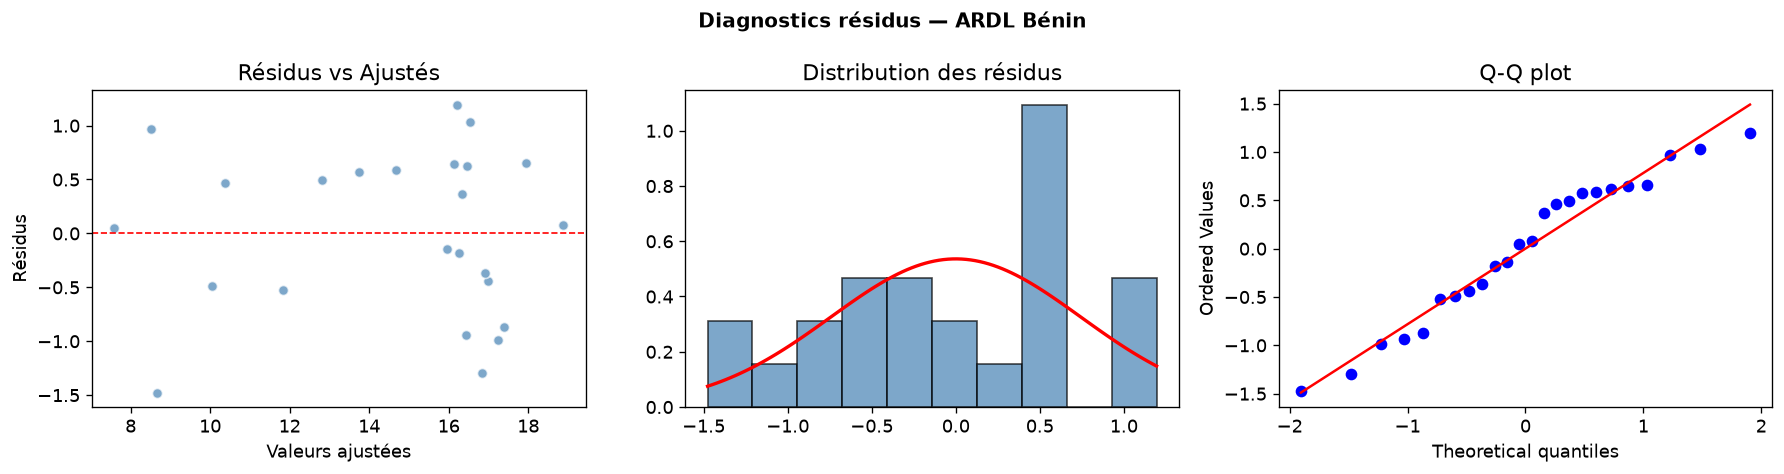

Durbin-Watson : 2.148  : OK
Jarque-Bera   : stat=1.337, p=0.5125  : normalité OK
Shapiro-Wilk  : p=0.3337  : OK


In [9]:
# resid_is_s et y_fitted_is calculés en 2.2 via X @ beta (pas via fittedvalues)
resid  = resid_is_s.values
fitted = y_fitted_is.values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(fitted, resid, alpha=0.7, color='steelblue', edgecolors='white')
axes[0].axhline(0, color='red', linestyle='--', lw=1)
axes[0].set_title('Résidus vs Ajustés')
axes[0].set_xlabel('Valeurs ajustées')
axes[0].set_ylabel('Résidus')

axes[1].hist(resid, bins=10, edgecolor='black', color='steelblue', alpha=0.7, density=True)
xn = np.linspace(resid.min(), resid.max(), 100)
axes[1].plot(xn, stats.norm.pdf(xn, resid.mean(), resid.std()), 'r-', lw=2)
axes[1].set_title('Distribution des résidus')

stats.probplot(resid, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot')

plt.suptitle('Diagnostics résidus - ARDL Bénin', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'ardl_residus.png', bbox_inches='tight')
plt.show()

dw        = durbin_watson(resid)
jb, jb_p  = stats.jarque_bera(resid)
_, sw_p   = stats.shapiro(resid)
print(f"Durbin-Watson : {dw:.3f}  {': autocorrélation probable' if dw < 1.5 else ': OK'}")
print(f"Jarque-Bera   : stat={jb:.3f}, p={jb_p:.4f}  {': normalité OK' if jb_p > 0.05 else ': non normal'}")
print(f"Shapiro-Wilk  : p={sw_p:.4f}  {': OK' if sw_p > 0.05 else ': non normal (T faible, non critique)'}")

### 2.6 Métriques in-sample


=== Métriques — ARDL Bénin — In-sample ===
  RMSE         0.7444
  MAE          0.6434
  R²           0.9504
  MAPE (%)     4.8347


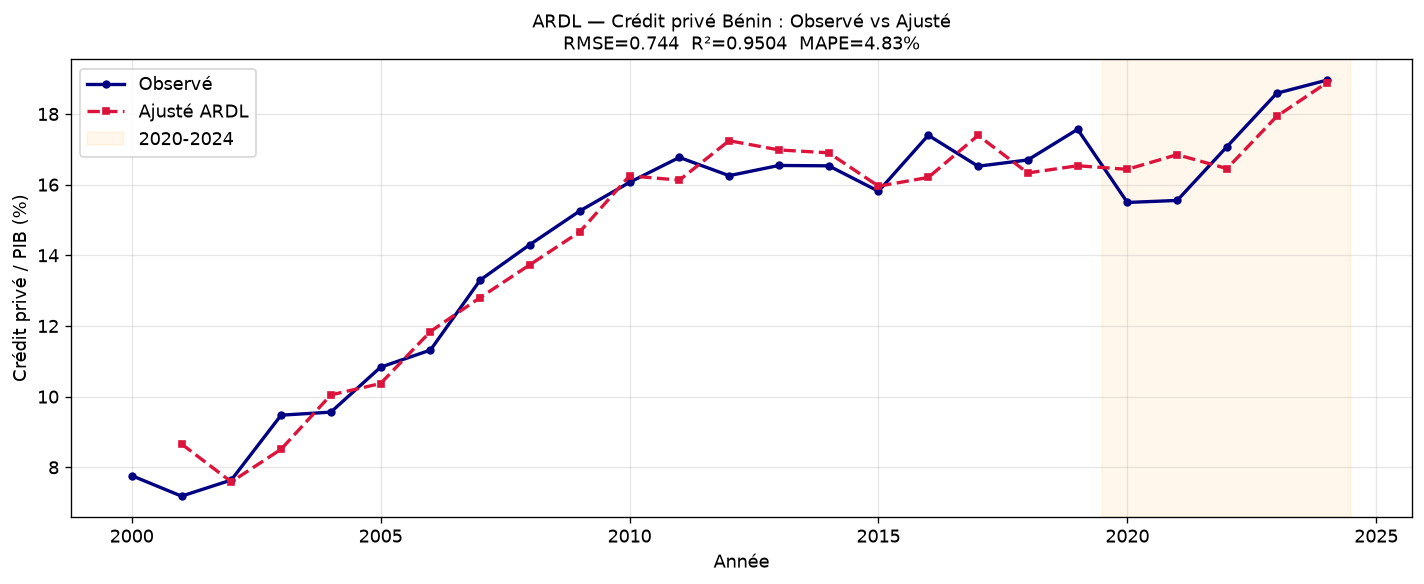

In [10]:
metrics_ardl_insample = compute_metrics(
    endog.loc[y_fitted_is.index], y_fitted_is,
    'ARDL Bénin - In-sample'
)

rmse_is = metrics_ardl_insample['RMSE']
r2_is_v = metrics_ardl_insample['R²']
mape_is = metrics_ardl_insample['MAPE (%)']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(endog.index, endog, 'o-', color='navy', lw=2, ms=4, label='Observé')
ax.plot(y_fitted_is.index, y_fitted_is, 's--', color='crimson', lw=2, ms=4, label='Ajusté ARDL')
ax.axvspan(2019.5, 2024.5, alpha=0.08, color='orange', label='2020-2024')
ax.set_title(
    f"ARDL - Crédit privé Bénin : Observé vs Ajusté\n"
    f"RMSE={rmse_is:.3f}  R²={r2_is_v:.4f}  MAPE={mape_is:.2f}%",
    fontsize=11
)
ax.set_xlabel('Année')
ax.set_ylabel('Crédit privé / PIB (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_PATH / 'ardl_actual_vs_fitted.png', bbox_inches='tight')
plt.show()


### 2.7 Validation hors-échantillon (2020-2024)

Re-estimation sur 2000-2019. Prévision récursive via `ardl_forecast_recursive()`.


=== Métriques — ARDL Bénin — Hors-échantillon (2020-2024) ===
  RMSE         3.0712
  MAE          3.0008
  R²           -3.4435
  MAPE (%)     17.6546


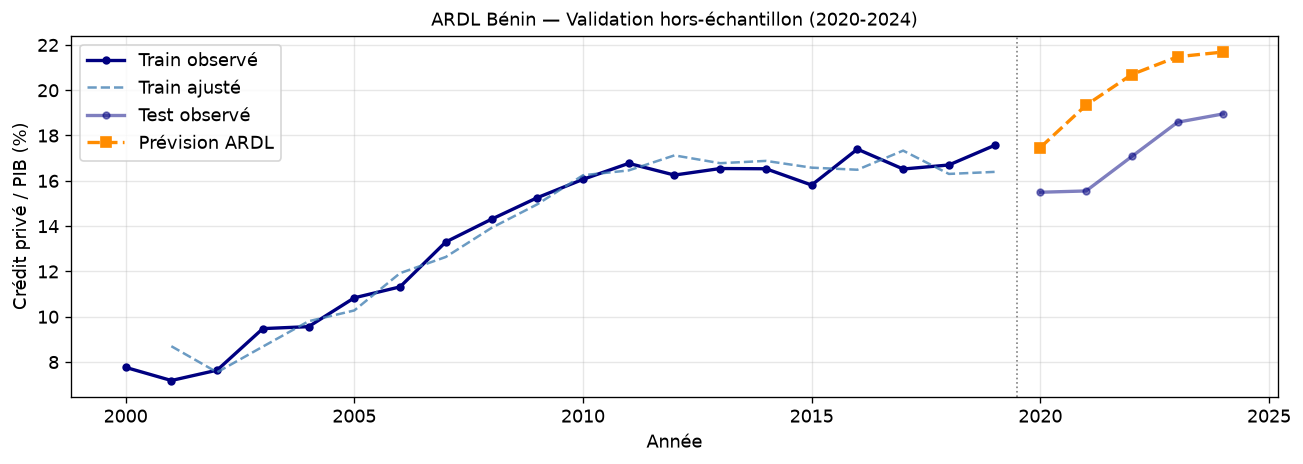

In [11]:
train_mask = benin_ardl.index <= 2019
test_mask  = benin_ardl.index >= 2020

endog_train = benin_ardl.loc[train_mask, 'credit_prive_pib']
exog_train  = benin_ardl.loc[train_mask, selected_exog_vars]
exog_test   = benin_ardl.loc[test_mask,  selected_exog_vars]

metrics_ardl_oos = {k: np.nan for k in ['RMSE', 'MAE', 'R²', 'MAPE (%)']}

try:
    ardl_train_model = ARDL(endog_train, lags=ar_order, exog=exog_train,
                             order=dl_order_sel, trend='c')
    ardl_train_res   = ardl_train_model.fit()

    # Prévision récursive manuelle (évite predict() / fittedvalues)
    f_vals = ardl_forecast_recursive(
        ardl_train_res, endog_train, exog_train, exog_test
    )

    # Ajusté train via X @ beta (même approche que ci-dessus)
    y_hat_tr, hb_tr, _ = ardl_fitted_manual(ardl_train_model, ardl_train_res,
                                              endog_train, exog_train)
    y_fit_tr = pd.Series(y_hat_tr, index=endog_train.index[hb_tr:])

    y_test_obs = benin_ardl.loc[test_mask, 'credit_prive_pib'].values
    metrics_ardl_oos = compute_metrics(
        y_test_obs, f_vals,
        'ARDL Bénin - Hors-échantillon (2020-2024)'
    )

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(endog_train.index, endog_train,
            'o-', color='navy', lw=2, ms=4, label='Train observé')
    ax.plot(y_fit_tr.index, y_fit_tr,
            '--', color='steelblue', lw=1.5, alpha=0.8, label='Train ajusté')
    ax.plot(benin_ardl.index[test_mask], y_test_obs,
            'o-', color='navy', lw=2, ms=4, alpha=0.5, label='Test observé')
    ax.plot(benin_ardl.index[test_mask], f_vals,
            's--', color='darkorange', lw=2, ms=6, label='Prévision ARDL')
    ax.axvline(2019.5, color='gray', linestyle=':', lw=1)
    ax.set_title('ARDL Bénin - Validation hors-échantillon (2020-2024)', fontsize=11)
    ax.set_xlabel('Année')
    ax.set_ylabel('Crédit privé / PIB (%)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_PATH / 'ardl_forecast_oos.png', bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f'Prévision OOS échouée : {e}')
    print(': Métriques in-sample uniquement pour ARDL.')


---
## 3. Panel Effets Fixes - UEMOA (N=8, T=25)

$credit_{it} = \alpha_i + \mathbf{X}'_{it}\boldsymbol{\beta} + \varepsilon_{it}$

Justification : Mundlak F=25.9 : FE ; Breusch-Pagan : SE clustered.

In [12]:
VARS_FE = [
    'pib_croissance', 'inflation_ipc', 'masse_monetaire_m2_pib',
    'imf_dette_publique', 'ouverture_commerciale', 'ide_pib',
    'wgi_controle_corruption', 'bceao_taux_directeur',
]

df_fe       = df[['iso3', 'annee', 'credit_prive_pib'] + VARS_FE].copy()
df_fe[VARS_FE] = df_fe.groupby('iso3')[VARS_FE].transform(
    lambda x: x.interpolate(method='linear', limit=2)
)
df_fe = df_fe.dropna().reset_index(drop=True)

df_train = df_fe[df_fe['annee'] <= 2019].copy()
df_test  = df_fe[df_fe['annee'] >= 2020].copy()

print(f'Panel FE : {df_fe.shape[0]} obs | {df_fe["iso3"].nunique()} pays | {df_fe["annee"].nunique()} années')
print(f'Train : {len(df_train)} obs | Test : {len(df_test)} obs')

Panel FE : 193 obs | 8 pays | 25 années
Train : 153 obs | Test : 40 obs


### 3.1 Estimation PanelOLS (effets fixes, SE clustered)

In [13]:
if LM_AVAILABLE:
    df_tr_idx  = df_train.set_index(['iso3', 'annee'])
    y_train_lm = df_tr_idx['credit_prive_pib']
    X_train_lm = df_tr_idx[VARS_FE]
    fe_model   = PanelOLS(y_train_lm, X_train_lm, entity_effects=True, time_effects=False)
    fe_res     = fe_model.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
else:
    print('Fallback : OLS within (dummies pays)')
    dummies  = pd.get_dummies(df_train['iso3'], prefix='d', drop_first=True, dtype=float)
    X_within = pd.concat([df_train[VARS_FE].reset_index(drop=True),
                          dummies.reset_index(drop=True)], axis=1)
    X_within = add_constant(X_within)
    fe_res   = OLS(df_train['credit_prive_pib'].values,
                   X_within.astype(float)).fit(cov_type='HC1')
    print(fe_res.summary())

                          PanelOLS Estimation Summary                           
Dep. Variable:       credit_prive_pib   R-squared:                        0.8297
Estimator:                   PanelOLS   R-squared (Between):              0.4950
No. Observations:                 153   R-squared (Within):               0.8297
Date:                Thu, Jun 18 2026   R-squared (Overall):              0.5136
Time:                        22:14:34   Log-likelihood                   -314.92
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      83.443
Entities:                           8   P-value                           0.0000
Avg Obs:                       19.125   Distribution:                   F(8,137)
Min Obs:                       15.000                                           
Max Obs:                       20.000   F-statistic (robust):         -5.258e+15
                            

### 3.2 Effets fixes par pays

=== Effets fixes estimés par pays ===
  SEN    +14.46 pp  ██████████████
  MLI    +13.25 pp  █████████████
  TGO    +12.38 pp  ████████████
  BFA    +11.81 pp  ███████████
  CIV    +10.29 pp  ██████████
  BEN    +10.01 pp  ██████████
  NER    + 9.19 pp  █████████
  GNB    + 1.13 pp  █


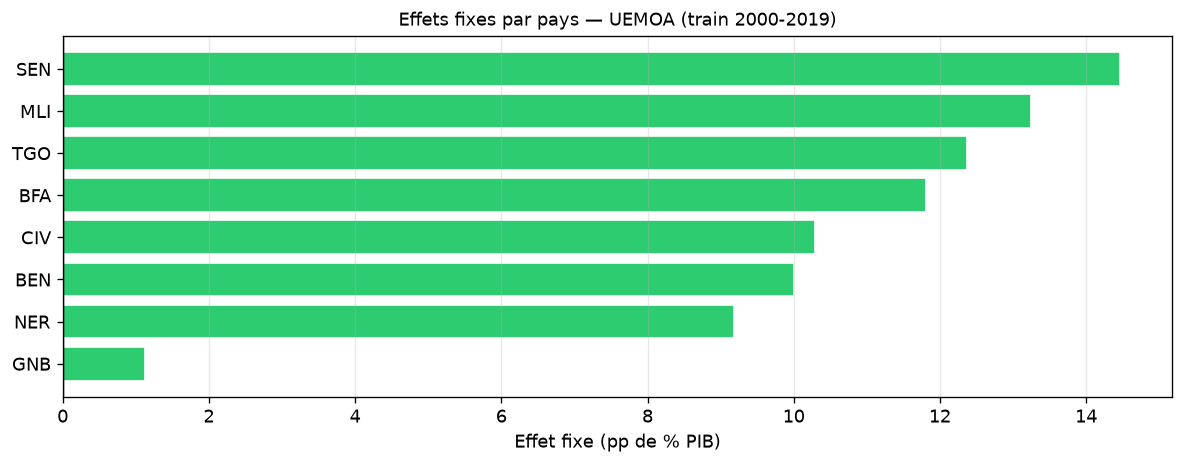

In [14]:
if LM_AVAILABLE:
    beta_fe = fe_res.params[VARS_FE].values
else:
    beta_fe = fe_res.params.values[1:1 + len(VARS_FE)]

entity_effects = {}
for pays in sorted(df_train['iso3'].unique()):
    mask = df_train['iso3'] == pays
    y_i  = df_train.loc[mask, 'credit_prive_pib'].values
    X_i  = df_train.loc[mask, VARS_FE].values
    entity_effects[pays] = float(y_i.mean() - X_i.mean(axis=0) @ beta_fe)

ef_series = pd.Series(entity_effects).sort_values(ascending=True)

print('=== Effets fixes estimés par pays ===')
for pays, ef in ef_series.sort_values(ascending=False).items():
    barre = '█' * max(0, int(abs(ef)))
    print(f"  {pays:<6} {'+'if ef>=0 else'-'}{abs(ef):5.2f} pp  {barre}")

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in ef_series.values]
ax.barh(ef_series.index, ef_series.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Effets fixes par pays - UEMOA (train 2000-2019)', fontsize=11)
ax.set_xlabel('Effet fixe (pp de % PIB)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_PATH / 'panel_effets_fixes.png', bbox_inches='tight')
plt.show()

### 3.3 Métriques de performance

In [15]:
# fitted_values de linearmodels = valeurs "within" (sans effets fixes) : R² trop faible
# On recalcule proprement : X @ beta + alpha_i (même approche que pour le test)
df_train_pred = df_train.copy()
df_train_pred['y_pred_fe'] = (
    df_train_pred[VARS_FE].values @ beta_fe
    + df_train_pred['iso3'].map(entity_effects).values
)
y_fitted_train = df_train_pred['y_pred_fe'].values

metrics_fe_train = compute_metrics(
    df_train['credit_prive_pib'].values, y_fitted_train,
    'Panel Effets Fixes - Train (2000-2019)'
)

df_test_pred = df_test.copy()
df_test_pred['y_pred_fe'] = (
    df_test_pred[VARS_FE].values @ beta_fe
    + df_test_pred['iso3'].map(entity_effects).values
)

metrics_fe_test = compute_metrics(
    df_test_pred['credit_prive_pib'].values,
    df_test_pred['y_pred_fe'].values,
    'Panel Effets Fixes - Test (2020-2024)'
)



=== Métriques — Panel Effets Fixes — Train (2000-2019) ===
  RMSE         1.8953
  MAE          1.4480
  R²           0.9241
  MAPE (%)     15.7736

=== Métriques — Panel Effets Fixes — Test (2020-2024) ===
  RMSE         2.4170
  MAE          1.9093
  R²           0.8772
  MAPE (%)     8.9583


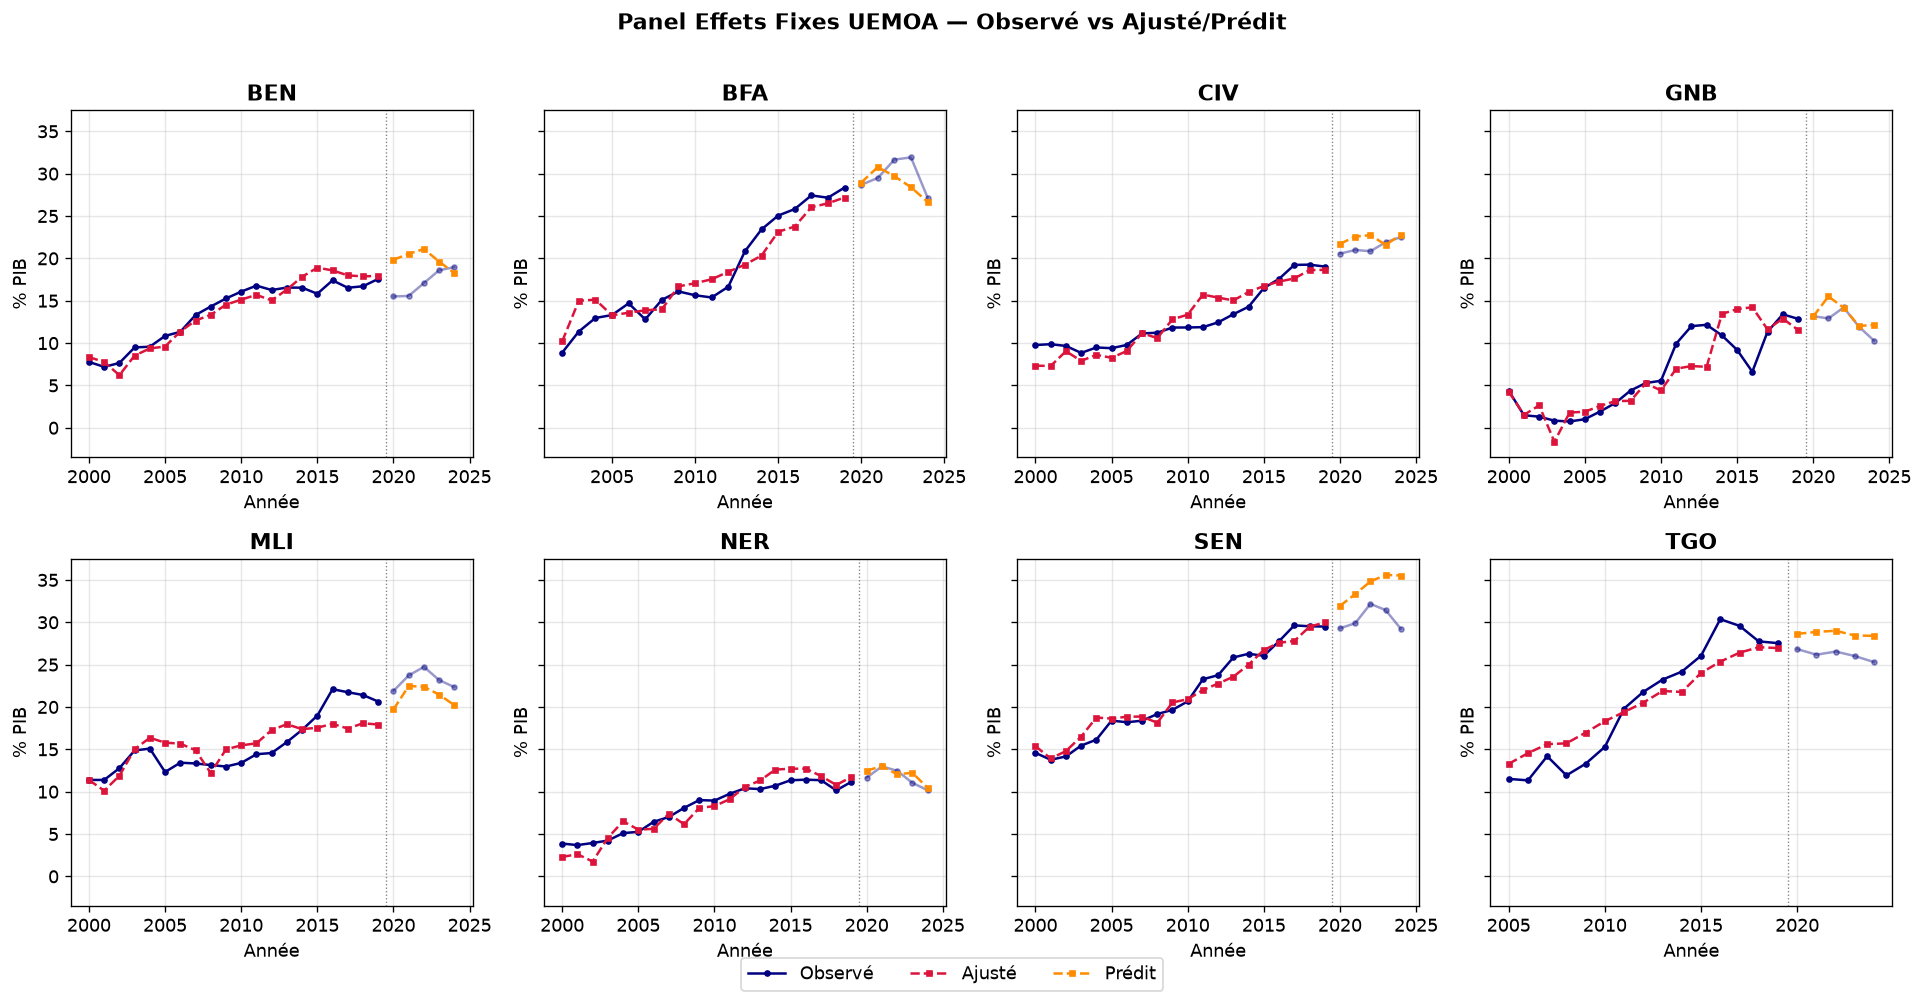

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
for ax, pays in zip(axes.flatten(), sorted(df_fe['iso3'].unique())):
    sub_tr = df_train_pred[df_train_pred['iso3'] == pays]
    sub_te = df_test_pred[df_test_pred['iso3'] == pays]
    ax.plot(sub_tr['annee'], sub_tr['credit_prive_pib'],
            'o-', color='navy', lw=1.5, ms=3, label='Observé')
    ax.plot(sub_tr['annee'], sub_tr['y_pred_fe'],
            's--', color='crimson', lw=1.5, ms=3, label='Ajusté')
    if len(sub_te) > 0:
        ax.plot(sub_te['annee'], sub_te['credit_prive_pib'],
                'o-', color='navy', lw=1.5, ms=3, alpha=0.4)
        ax.plot(sub_te['annee'], sub_te['y_pred_fe'],
                's--', color='darkorange', lw=1.5, ms=3, label='Prédit')
        ax.axvline(2019.5, color='gray', linestyle=':', lw=0.8)
    ax.set_title(pays, fontweight='bold')
    ax.set_xlabel('Année')
    ax.set_ylabel('% PIB')
    ax.grid(alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Panel Effets Fixes UEMOA - Observé vs Ajusté/Prédit',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_PATH / 'panel_fe_actual_vs_fitted.png', bbox_inches='tight')
plt.show()


---
## 4. Synthèse comparative

TABLE COMPARATIVE — MODÈLES ÉCONOMÉTRIQUES
                         Modèle        Périmètre   RMSE    MAE      R²  MAPE (%)
       ARDL — Bénin (in-sample) 2000-2024 (T≈23) 0.7444 0.6434  0.9504    4.8347
ARDL — Bénin (hors-échantillon)  2020-2024 (T=5) 3.0712 3.0008 -3.4435   17.6546
       Panel FE — UEMOA (train)  2000-2019 (N=8) 1.8953 1.4480  0.9241   15.7736
        Panel FE — UEMOA (test)  2020-2024 (N=8) 2.4170 1.9093  0.8772    8.9583


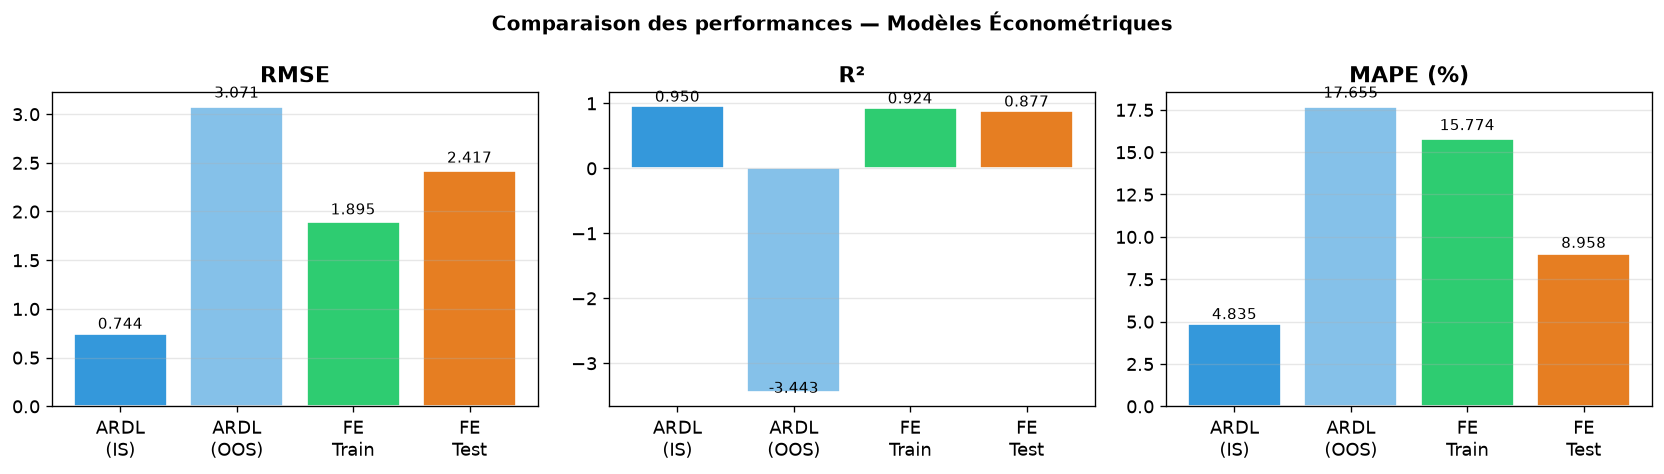

In [17]:
synthesis = pd.DataFrame([
    {'Modèle': 'ARDL - Bénin (in-sample)',       'Périmètre': '2000-2024 (T≈23)',
     **{k: round(v, 4) for k, v in metrics_ardl_insample.items()}},
    {'Modèle': 'ARDL - Bénin (hors-échantillon)', 'Périmètre': '2020-2024 (T=5)',
     **{k: round(v, 4) for k, v in metrics_ardl_oos.items()}},
    {'Modèle': 'Panel FE - UEMOA (train)',        'Périmètre': '2000-2019 (N=8)',
     **{k: round(v, 4) for k, v in metrics_fe_train.items()}},
    {'Modèle': 'Panel FE - UEMOA (test)',         'Périmètre': '2020-2024 (N=8)',
     **{k: round(v, 4) for k, v in metrics_fe_test.items()}},
])

print('=' * 85)
print('TABLE COMPARATIVE - MODÈLES ÉCONOMÉTRIQUES')
print('=' * 85)
print(synthesis.to_string(index=False))
print('=' * 85)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels_p  = ['ARDL\n(IS)', 'ARDL\n(OOS)', 'FE\nTrain', 'FE\nTest']
colors_p  = ['#3498db', '#85c1e9', '#2ecc71', '#e67e22']

for ax, metric in zip(axes, ['RMSE', 'R\u00b2', 'MAPE (%)']):
    vals       = synthesis[metric].values.astype(float)
    valid      = ~np.isnan(vals)
    bars       = ax.bar([l for l, v in zip(labels_p, valid) if v],
                        vals[valid],
                        color=[c for c, v in zip(colors_p, valid) if v],
                        edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    for bar, val in zip(bars, vals[valid]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Comparaison des performances - Modèles Économétriques', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'econometrie_synthese_metriques.png', bbox_inches='tight')
plt.show()

## 5. Conclusions

| Constat | Implication RF / XGBoost |
|---------|---------------------------|
| Variables I(1) mixtes | ML sur niveaux + `credit.L1` comme feature |
| Effets fixes significatifs | Inclure `iso3` encodé |
| masse_monetaire r=+0.775 | Feature importance attendue élevée |
| bceao_taux r=−0.569 | Surveiller l'importance SHAP |

**Notebook 04 - Random Forest + XGBoost**